In [4]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/py312_env/bin/python
3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


# Notebook for Redoing EDA and such after 2.3 Feature Engineering

In [27]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
from src.features import feature_encoder, raw_data_loader
%matplotlib inline

In [6]:
df = raw_data_loader.load_and_clean_raw("..")

df_imputed = feature_encoder.encode_features(df.copy(), impute=True)
df = feature_encoder.encode_features(df.copy(), impute=False)


In [7]:
profile = ProfileReport(df, title="Sleep Apnea Dataset Profiling Report", explorative=True)

In [8]:
profile.to_file("../reports/3.0-profile-report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 149/149 [00:00<00:00, 335.28it/s]
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/opt/anaconda3/envs/py312_env/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicate

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

things of note/todo: 
1. check handling of -55 / missing values and what they represent in the data dictionary
2. better check for outliers 
3. the -55 placeholders and similar are usually rperesentative of "idk" so maybe try encoding them differently

also stuff from the end of 2.3 notebook
1. Feature selection before FA — use only the ~6 top SHAP factors' original variables as input to FA, rather than all features. Less noise going in
2. smoteenn or smotetomek?
3. lightgbm maybe 
4. stacking ensembles 
5. cross-validate shap values

In [37]:
from sklearn.ensemble import IsolationForest
import numpy as np

df_imputed = df_imputed.copy()
X_raw = df_imputed.drop(columns=["ahi"]).copy()

# Step 1 Baseline: properly parameterized IsolationForest
clf_baseline = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
clf_baseline.fit(X_raw)


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: scores + PCA projection (2D) used for all visualizations below
baseline_labels = clf_baseline.predict(X_raw)
baseline_scores = clf_baseline.decision_function(X_raw)

pca_raw = PCA(n_components=2, random_state=42)
X_raw_2d = pca_raw.fit_transform(X_raw)

print("Step 1 — Baseline IsolationForest (raw features, n_estimators=200, contamination=5%)")
print(pd.Series(baseline_labels).map({1: "Normal", -1: "Outlier"}).value_counts().to_string())


Step 1 — Baseline IsolationForest (raw features, n_estimators=200, contamination=5%)
Normal     1602
Outlier      85


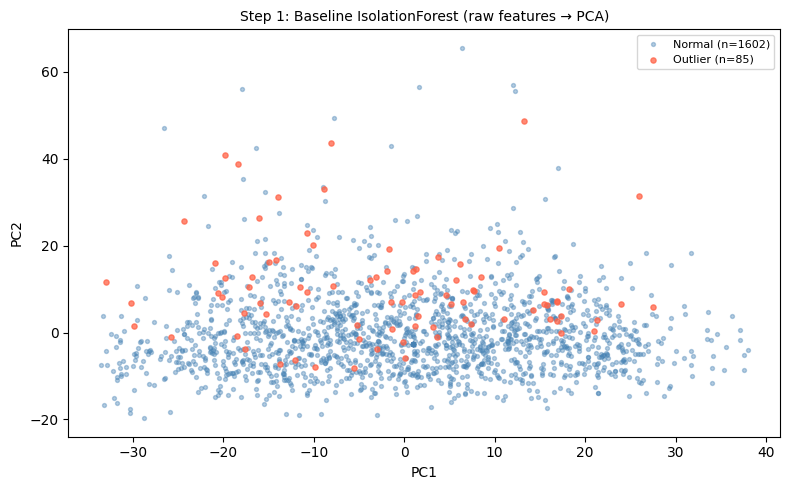

In [ ]:
from src.plots import plot_outliers

fig, ax = plt.subplots(figsize=(8, 5))
plot_outliers(X_raw_2d, baseline_labels, "Step 1: Baseline IsolationForest (raw features → PCA)", ax)
plt.tight_layout()
plt.show()


need to encode better probably gah
try multiple approaches prolly because ther er now way there r that many anomalies
- adding more estimators to iso forest significantly improved results

---
## Outlier Detection — Step-by-Step Improvement Framework

Each step builds on the previous and results are compared visually.

| Step | Change | Purpose |
|------|--------|---------|
| 0 | Sentinel value check | Confirm -55/-66 placeholders aren't skewing detection |
| 1 | Baseline IsolationForest (raw features) | Reference point |
| 2 | IsolationForest on FA factor scores | Remove high-dim noise |
| 3 | Consensus voting — IForest + LOF + ECOD | Reduce method-specific false positives |
| 4 | Class-conditional detection | Detect outliers *within* each AHI severity group |


### Step 0: Sentinel Value Check

`feature_encoder` should have replaced -55 and -66 with NaN before imputation. Confirming here — any remaining sentinels will appear as extreme numeric outliers and flood the detector.


In [ ]:
from src.utils.data_utils import check_sentinel_values

# Step 0: confirm no -55 / -66 sentinel values remain in the imputed dataset
check_sentinel_values(df_imputed)


✓ No -55 or -66 sentinel values remain — feature_encoder already handled them.


### Step 2: Detection in Factor Space

Running IsolationForest on the 18 FA factor scores instead of ~130 raw features. FA compresses correlated features and removes noise, giving cleaner outlier boundaries in lower-dimensional space.


Step 2 — IsolationForest on 18 FA factor scores
Normal     1602
Outlier      85


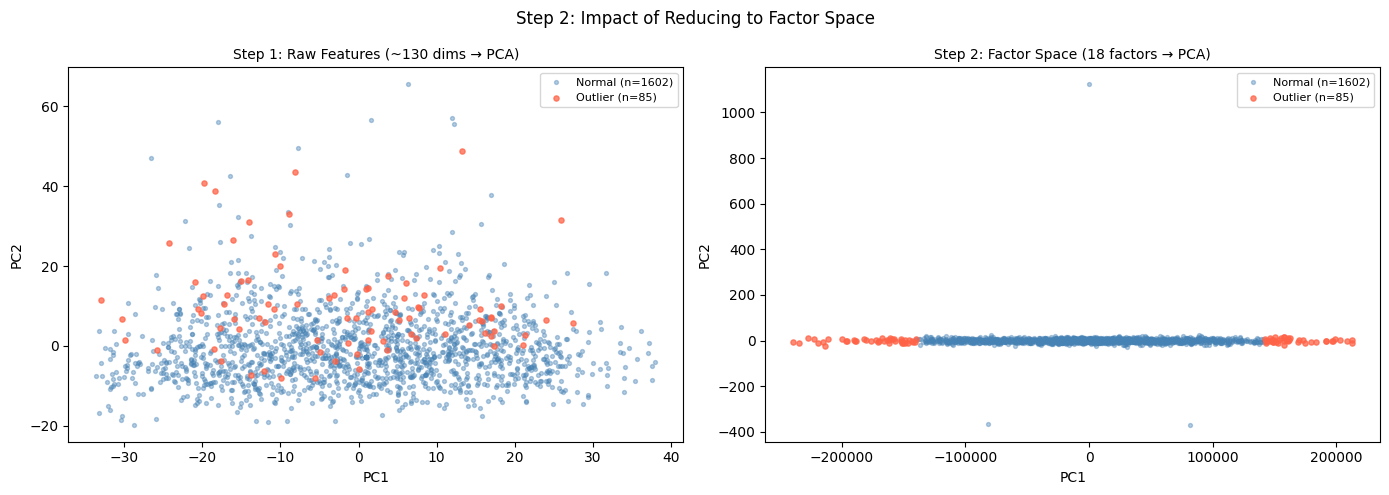

In [42]:
from src.features.transformers import Factor_Analyzer_Transformer

# Fit FA on raw features, extract only the 18 factor score columns
fa = Factor_Analyzer_Transformer(n_factors=18, rotation="varimax")
fa.fit(X_raw)
X_fa_full = fa.transform(X_raw)
factor_cols = [c for c in X_fa_full.columns if c.startswith("factor_")]
X_fa = X_fa_full[factor_cols].values  # shape: (n, 18)

# PCA on factor scores for 2D visualization
pca_fa = PCA(n_components=2, random_state=42)
X_fa_2d = pca_fa.fit_transform(X_fa)

# IsolationForest on factor space
clf_fa = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
clf_fa.fit(X_fa)
fa_labels = clf_fa.predict(X_fa)

print("Step 2 — IsolationForest on 18 FA factor scores")
print(pd.Series(fa_labels).map({1: "Normal", -1: "Outlier"}).value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_outliers(X_raw_2d, baseline_labels, "Step 1: Raw Features (~130 dims → PCA)", axes[0])
plot_outliers(X_fa_2d, fa_labels, "Step 2: Factor Space (18 factors → PCA)", axes[1])
plt.suptitle("Step 2: Impact of Reducing to Factor Space", fontsize=12)
plt.tight_layout()
plt.show()


### Step 3: Consensus Voting (pyod)

Running three independent detectors on the factor scores and flagging rows where **≥2/3 agree**. This reduces method-specific false positives.

- **IsolationForest** — tree-based, global anomalies
- **LOF (Local Outlier Factor)** — density-based, local neighborhoods
- **ECOD** — empirical CDF-based, no hyperparameters, fast


Per-detector outlier counts (pyod: 1=outlier):
  IForest   :   85 outliers (5.0%)
  LOF       :   85 outliers (5.0%)
  ECOD      :   84 outliers (5.0%)

Consensus (≥2/3): 84 outliers (5.0%)


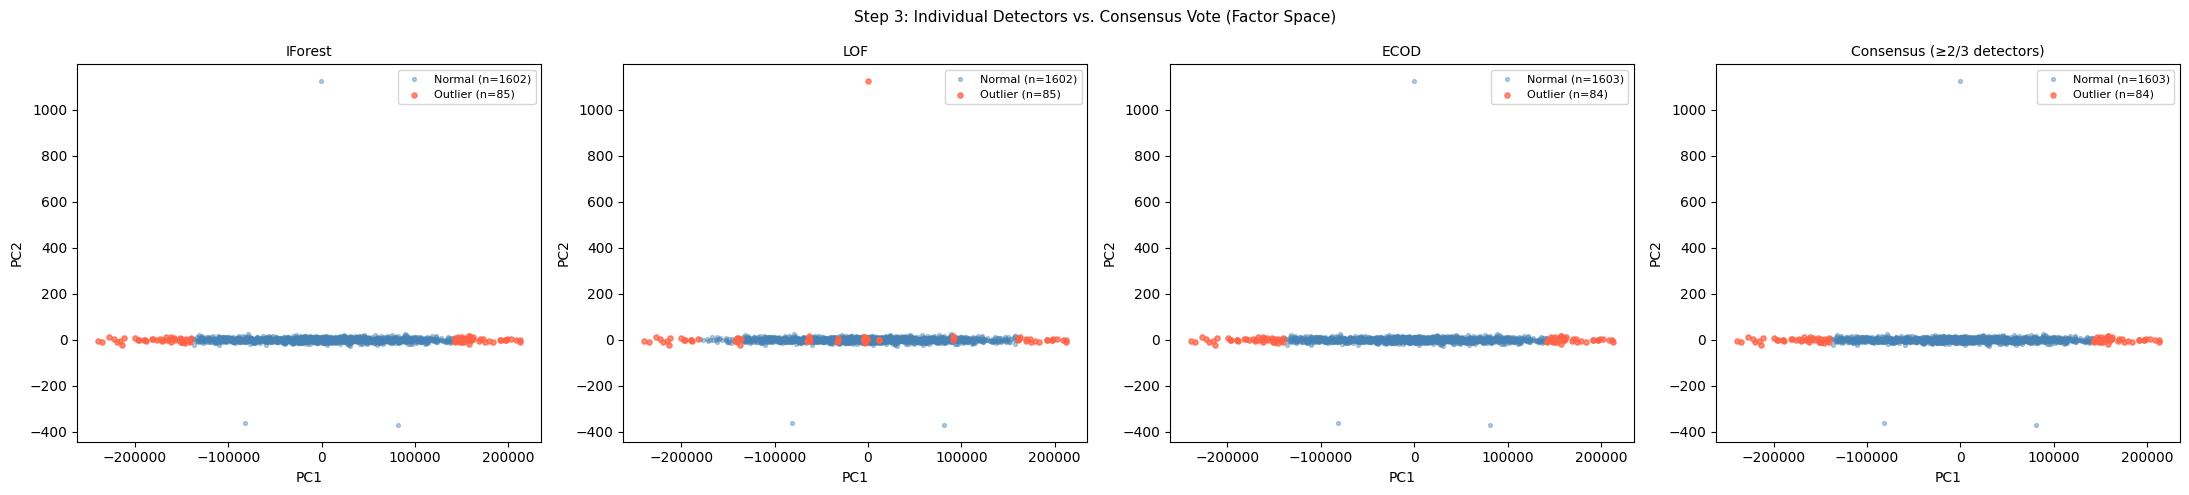

In [43]:
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD

CONTAMINATION = 0.05
detectors = {
    "IForest": IForest(n_estimators=200, contamination=CONTAMINATION, random_state=42),
    "LOF":     LOF(contamination=CONTAMINATION),
    "ECOD":    ECOD(contamination=CONTAMINATION),
}

vote_df = pd.DataFrame(index=range(len(X_fa)))
for name, det in detectors.items():
    det.fit(X_fa)
    vote_df[name] = det.labels_  # pyod convention: 1=outlier, 0=inlier

vote_df["votes"] = vote_df[list(detectors.keys())].sum(axis=1)
# Convert to sklearn convention (1=normal, -1=outlier) for plot_outliers
consensus_labels = np.where(vote_df["votes"] >= 2, -1, 1)

print("Per-detector outlier counts (pyod: 1=outlier):")
for name in detectors:
    n_out = int(vote_df[name].sum())
    print(f"  {name:10s}: {n_out:4d} outliers ({100 * n_out / len(X_fa):.1f}%)")
print(f"\nConsensus (≥2/3): {(consensus_labels == -1).sum()} outliers "
      f"({100 * (consensus_labels == -1).sum() / len(X_fa):.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, name in enumerate(detectors):
    lbls = np.where(vote_df[name] == 1, -1, 1)  # pyod → sklearn convention
    plot_outliers(X_fa_2d, lbls, name, axes[i])
plot_outliers(X_fa_2d, consensus_labels, "Consensus (≥2/3 detectors)", axes[3])
plt.suptitle("Step 3: Individual Detectors vs. Consensus Vote (Factor Space)", fontsize=11)
plt.tight_layout()
plt.show()


### Step 4: Class-Conditional Detection

Detecting outliers *within* each AHI severity class (none / mild / moderate / severe) rather than globally. A severe-apnea patient may look globally "abnormal" but be entirely typical within their class.


Step 4 — Class-conditional IsolationForest (factor space, contamination=5%):
  none     (n= 574):  29 outliers (5.1%)
  mild     (n= 536):  27 outliers (5.0%)
  moderate (n= 316):  16 outliers (5.1%)
  severe   (n= 261):  13 outliers (5.0%)

Total: 85 outliers (5.0%)


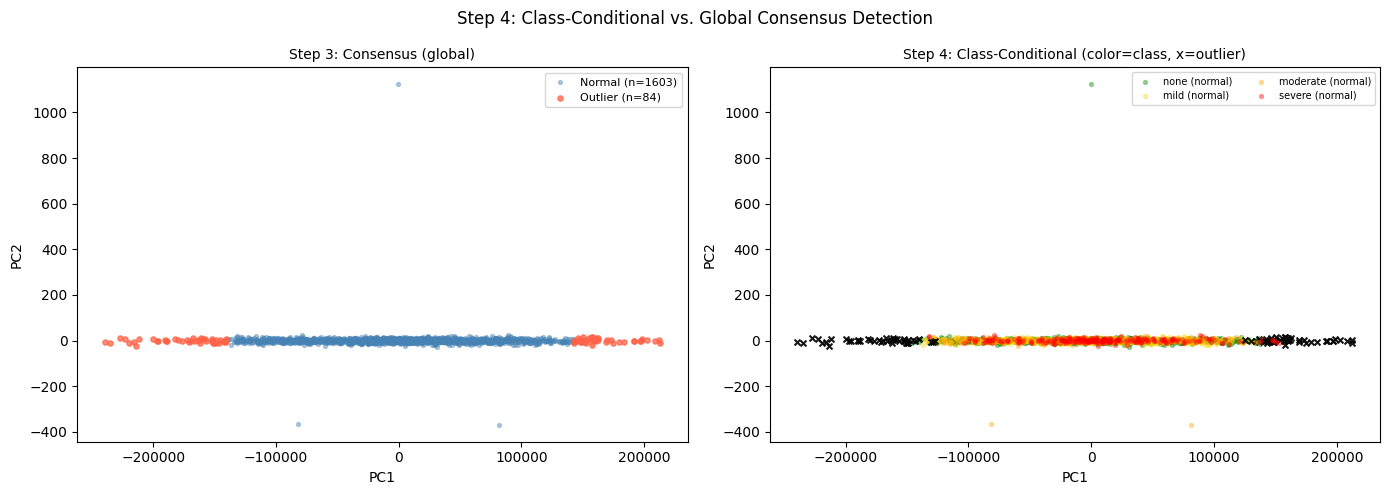

In [ ]:
from src.utils.data_utils import ahi_to_severity
from src.utils.eda_utils import class_conditional_iforest

y_sev = df_imputed["ahi"].map(ahi_to_severity)
class_outlier_labels = class_conditional_iforest(X_fa, y_sev, contamination=CONTAMINATION)

# Color-code the class-conditional plot by AHI class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_outliers(X_fa_2d, consensus_labels, "Step 3: Consensus (global)", axes[0])

# Step 4: overlay class identity with outlier status
class_colors = {"none": "green", "mild": "gold", "moderate": "orange", "severe": "red"}
for cls in ["none", "mild", "moderate", "severe"]:
    mask = (y_sev == cls).values
    normal_mask = mask & (class_outlier_labels == 1)
    outlier_mask = mask & (class_outlier_labels == -1)
    axes[1].scatter(X_fa_2d[normal_mask, 0], X_fa_2d[normal_mask, 1],
                    s=8, alpha=0.35, c=class_colors[cls], label=f"{cls} (normal)")
    axes[1].scatter(X_fa_2d[outlier_mask, 0], X_fa_2d[outlier_mask, 1],
                    s=18, alpha=0.9, c="black", marker="x")
axes[1].set_title("Step 4: Class-Conditional (color=class, x=outlier)", fontsize=10)
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.suptitle("Step 4: Class-Conditional vs. Global Consensus Detection", fontsize=12)
plt.tight_layout()
plt.show()


### Summary: Outlier Rate Comparison Across All Methods


Total samples: 1687

                             Method  Outliers  Normal  Outlier %
    Step 1: Baseline (raw, IForest)        85    1602        5.0
     Step 2: Factor Space (IForest)        85    1602        5.0
             Step 3: IForest (pyod)        85    1602        5.0
                 Step 3: LOF (pyod)        85    1602        5.0
                Step 3: ECOD (pyod)        84    1603        5.0
           Step 3: Consensus (≥2/3)        84    1603        5.0
Step 4: Class-Conditional (IForest)        85    1602        5.0


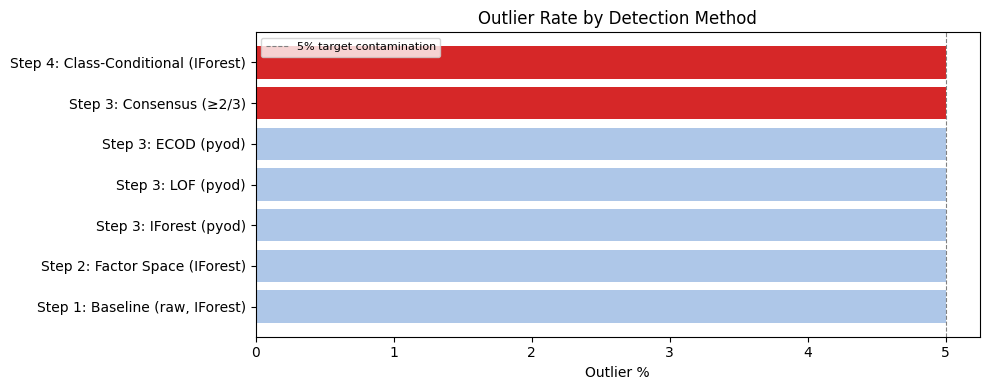

In [45]:
n_total = len(X_fa)

summary = pd.DataFrame([
    {"Method": "Step 1: Baseline (raw, IForest)",      "Outliers": int((baseline_labels == -1).sum())},
    {"Method": "Step 2: Factor Space (IForest)",        "Outliers": int((fa_labels == -1).sum())},
    {"Method": "Step 3: IForest (pyod)",                "Outliers": int(vote_df["IForest"].sum())},
    {"Method": "Step 3: LOF (pyod)",                    "Outliers": int(vote_df["LOF"].sum())},
    {"Method": "Step 3: ECOD (pyod)",                   "Outliers": int(vote_df["ECOD"].sum())},
    {"Method": "Step 3: Consensus (≥2/3)",              "Outliers": int((consensus_labels == -1).sum())},
    {"Method": "Step 4: Class-Conditional (IForest)",   "Outliers": int((class_outlier_labels == -1).sum())},
])
summary["Normal"] = n_total - summary["Outliers"]
summary["Outlier %"] = (summary["Outliers"] / n_total * 100).round(1)

print(f"Total samples: {n_total}\n")
print(summary.to_string(index=False))

# Bar chart of outlier rates
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728" if "Consensus" in m or "Class" in m else "#aec7e8" for m in summary["Method"]]
ax.barh(summary["Method"], summary["Outlier %"], color=colors)
ax.axvline(5, linestyle="--", color="gray", linewidth=0.8, label="5% target contamination")
ax.set_xlabel("Outlier %")
ax.set_title("Outlier Rate by Detection Method")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Step 5: Are the Same Rows Being Flagged Across Methods?

Building an outlier membership matrix (one boolean column per method) and then comparing overlap.


In [ ]:
from src.utils.eda_utils import build_outlier_flags, jaccard_similarity_matrix

# Normalise all to boolean True=outlier regardless of sklearn (-1) vs pyod (1) convention
outlier_flags = build_outlier_flags({
    "Step1_Baseline":    baseline_labels == -1,
    "Step2_FactorSpace": fa_labels == -1,
    "Step3_IForest":     vote_df["IForest"].astype(bool).values,
    "Step3_LOF":         vote_df["LOF"].astype(bool).values,
    "Step3_ECOD":        vote_df["ECOD"].astype(bool).values,
    "Step3_Consensus":   consensus_labels == -1,
    "Step4_ClassCond":   class_outlier_labels == -1,
}, index=X_raw.index)

method_cols = [c for c in outlier_flags.columns if c != "n_methods"]

print(f"Total rows: {len(outlier_flags)}")
print(f"\nRows flagged by EXACTLY N methods:")
print(outlier_flags["n_methods"].value_counts().sort_index().to_string())

agreement = jaccard_similarity_matrix(outlier_flags[method_cols])
print("\nPairwise Jaccard similarity (1.0 = identical sets):")
print(agreement.round(2).to_string())


Total rows: 1687

Rows flagged by EXACTLY N methods:
n_methods
0    1468
1     132
2       2
4       8
5      39
6      36
7       2

Pairwise Jaccard similarity (1.0 = identical sets):
                   Step1_Baseline  Step2_FactorSpace  Step3_IForest  Step3_LOF  Step3_ECOD  Step3_Consensus  Step4_ClassCond
Step1_Baseline               1.00               0.04           0.04       0.01        0.03             0.03             0.05
Step2_FactorSpace            0.04               1.00           1.00       0.28        0.99             0.99             0.81
Step3_IForest                0.04               1.00           1.00       0.28        0.99             0.99             0.81
Step3_LOF                    0.01               0.28           0.28       1.00        0.28             0.28             0.26
Step3_ECOD                   0.03               0.99           0.99       0.28        1.00             1.00             0.80
Step3_Consensus              0.03               0.99           0

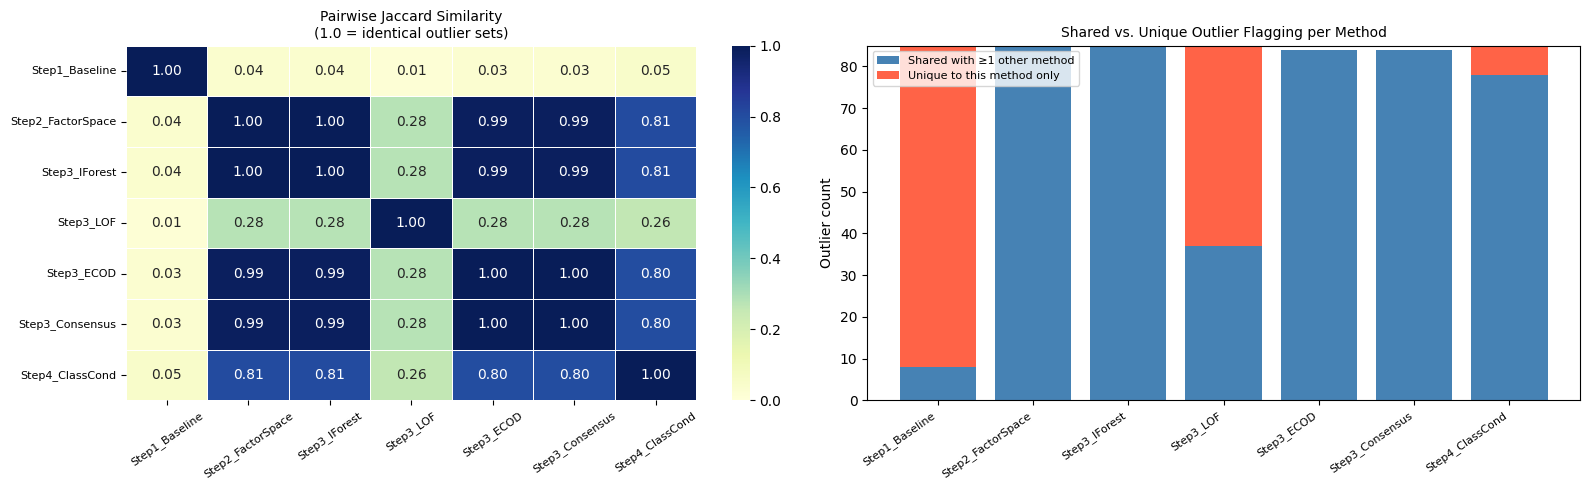

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Jaccard heatmap
sns.heatmap(
    agreement.astype(float),
    annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0, vmax=1, linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Pairwise Jaccard Similarity\n(1.0 = identical outlier sets)", fontsize=10)
axes[0].tick_params(axis="x", rotation=35, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# Right: stacked bar showing unique/shared flagging per method
unique_only = {m: int((outlier_flags[m] & (outlier_flags["n_methods"] == 1)).sum()) for m in method_cols}
shared = {m: int(outlier_flags[m].sum()) - unique_only[m] for m in method_cols}
x = range(len(method_cols))
axes[1].bar(x, [shared[m] for m in method_cols], label="Shared with ≥1 other method", color="steelblue")
axes[1].bar(x, [unique_only[m] for m in method_cols], bottom=[shared[m] for m in method_cols],
            label="Unique to this method only", color="tomato")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(method_cols, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Outlier count")
axes[1].set_title("Shared vs. Unique Outlier Flagging per Method", fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [48]:
# Actual row inspection: samples flagged by ALL methods, NONE, or uniquely by one
flagged_all   = outlier_flags[outlier_flags["n_methods"] == len(method_cols)].index
flagged_none  = outlier_flags[outlier_flags["n_methods"] == 0].index
flagged_unique = {
    m: outlier_flags[(outlier_flags[m]) & (outlier_flags["n_methods"] == 1)].index
    for m in method_cols
}

print(f"Flagged by ALL {len(method_cols)} methods: {len(flagged_all)} rows")
print(f"Flagged by NO method:                  {len(flagged_none)} rows")
print()

# Key columns to display alongside flags
key_cols = ["ahi"] + [c for c in ["age", "bmi", "sex"] if c in df_imputed.columns]

if len(flagged_all) > 0:
    print(f"── Rows flagged by every method (n={len(flagged_all)}) ──")
    display_df = df_imputed.loc[flagged_all, key_cols].copy()
    display_df["ahi_class"] = display_df["ahi"].map(ahi_to_severity)
    display_df["n_methods"] = outlier_flags.loc[flagged_all, "n_methods"]
    print(display_df.head(20).to_string())
    print()

print("── Rows unique to each method (not flagged by any other) ──")
for m in method_cols:
    idx = flagged_unique[m]
    print(f"  {m}: {len(idx)} unique rows")
    if len(idx) > 0:
        sample = df_imputed.loc[idx, key_cols].head(5).copy()
        sample["ahi_class"] = sample["ahi"].map(ahi_to_severity)
        print(sample.to_string())
        print()


Flagged by ALL 7 methods: 2 rows
Flagged by NO method:                  1468 rows

── Rows flagged by every method (n=2) ──
      ahi   age   bmi  sex ahi_class  n_methods
1299  6.1  67.0  31.8  1.0      mild          7
1505  4.3  49.0  19.1  1.0      none          7

── Rows unique to each method (not flagged by any other) ──
  Step1_Baseline: 77 unique rows
     ahi   age   bmi  sex ahi_class
22  10.6  32.0  34.5  0.0      mild
48  49.4  37.0  51.8  1.0    severe
50   0.9  51.0  25.7  1.0      none
54   0.0  51.0  36.3  0.0      none
74  10.4  49.0  29.6  0.0      mild

  Step2_FactorSpace: 0 unique rows
  Step3_IForest: 0 unique rows
  Step3_LOF: 48 unique rows
      ahi   age   bmi  sex ahi_class
0     0.3  58.0  30.7  1.0      none
55    0.7  36.0  29.6  1.0      none
65   21.7  32.0  24.1  1.0  moderate
85    7.7  69.0  34.8  1.0      mild
206   2.1  51.0  30.6  1.0      none

  Step3_ECOD: 0 unique rows
  Step3_Consensus: 0 unique rows
  Step4_ClassCond: 7 unique rows
       ahi

In [51]:
# manually looking through the flagged outliers 
step4_flagged_outliers = df_imputed[class_outlier_labels == -1].copy()
step4_flagged_outliers["ahi_class"] = step4_flagged_outliers["ahi"].map(ahi_to_severity)
print(f"Step 4 flagged outliers by AHI class:")

step4_flagged_outliers.head()

Step 4 flagged outliers by AHI class:


,age,bmi,sex,sw_9am_start_diff,sw_5pm_end_diff,nasal_congestion_stuffiness_nose,nasal_blockage_obstr_nose,troub_brth_nose,troub_slp_nose,not_enough_air_excercise_nose,...,chronic_obstructive_pulmonary_disease_mdhx,asthma_mdhx,cardiovascular_problem_other_mdhx,congestive_heart_failure_mdhx,hypertension_mdhx,oophorectomy_bilateral_mdhx,ahi,dream_recall_frequency_infrequent,dream_recall_frequency_rarely_or_never,ahi_class
28,32.0,41.5,1.0,-1.5,-2.5,2.0,2.0,3.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.9,1.0,0.0,none
45,60.0,24.9,1.0,1.0,0.0,3.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.1,0.0,0.0,mild
103,45.0,35.5,1.0,-1.0,0.0,2.0,0.0,1.0,3.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,9.8,1.0,0.0,mild
106,52.0,37.2,1.0,-1.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.3,0.0,1.0,none
178,42.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none


In [52]:
# iqr testing for column
Q1 = X_raw.quantile(0.25)
Q3 = X_raw.quantile(0.75)
IQR = Q3 - Q1

In [60]:
flagged_numeric = step4_flagged_outliers[X_raw.columns]
outliers = (flagged_numeric < (Q1 - 1.5 * IQR)) | (flagged_numeric > (Q3 + 1.5 * IQR))

iqr_outliers_df = outliers.sum().reset_index()
iqr_outliers_df.columns = ["feature", "n_iqr_outliers"]
iqr_outliers_df = iqr_outliers_df.sort_values(by="n_iqr_outliers", ascending=False)


display(iqr_outliers_df)

,feature,n_iqr_outliers
44,fall_asleep_driving_map,46
15,eating_impact_alertness,46
20,easily_awake_after_nap,43
4,sw_5pm_end_diff,38
84,slow_move_or_speak_freq_phq,34
...,...,...
57,sleep_problem_intereferes_with_daily_functioni...,0
56,how_worried_about_current_sleep_problem_isi,0
55,how_noticeable_is_sleep_problem_impacting_qual...,0
54,how_satisfied_with_curr_sleep_pattern_isi,0


In [ ]:
""" 
most outliers come in the fall_asleep_driving_map column

samples of note:
1560: 12 servings of caffeine per day
1562: work starts at 8 am and ends at 5am idk maybe look at those columns in their entirety
0435: gets 2 hours of sleep (severe ahi though)

"""

In [61]:
flagged_numeric_severe = step4_flagged_outliers[y_sev == "severe"][X_raw.columns]
outliers_severe = (flagged_numeric_severe < (Q1 - 1.5 * IQR)) | (flagged_numeric_severe > (Q3 + 1.5 * IQR))

flagged_numeric_moderate = step4_flagged_outliers[y_sev == "moderate"][X_raw.columns]
outliers_moderate = (flagged_numeric_moderate < (Q1 - 1.5 * IQR)) | (flagged_numeric_moderate > (Q3 + 1.5 * IQR))

flagged_numeric_mild = step4_flagged_outliers[y_sev == "mild"][X_raw.columns]
outliers_mild = (flagged_numeric_mild < (Q1 - 1.5 * IQR)) | (flagged_numeric_mild > (Q3 + 1.5 * IQR))

flagged_numeric_none = step4_flagged_outliers[y_sev == "none"][X_raw.columns]
outliers_none = (flagged_numeric_none < (Q1 - 1.5 * IQR)) | (flagged_numeric_none > (Q3 + 1.5 * IQR))

/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_64103/1999113954.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flagged_numeric_severe = step4_flagged_outliers[y_sev == "severe"][X_raw.columns]
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_64103/1999113954.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flagged_numeric_moderate = step4_flagged_outliers[y_sev == "moderate"][X_raw.columns]
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_64103/1999113954.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flagged_numeric_mild = step4_flagged_outliers[y_sev == "mild"][X_raw.columns]
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_64103/1999113954.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flagged_numeric_none = step4_flagged_outliers[y_sev == "none"][X_raw.columns]


In [63]:
display(flagged_numeric_severe.shape)
display(flagged_numeric_moderate.shape)
display(flagged_numeric_mild.shape)
display(flagged_numeric_none.shape)

(13, 148)

(16, 148)

(27, 148)

(29, 148)

In [69]:
# extreme iqr outliers
extreme_outliers = (flagged_numeric < (Q1 - 3 * IQR)) | (flagged_numeric > (Q3 + 3 * IQR))

ex_iqr_outliers_df = extreme_outliers.sum().reset_index()
ex_iqr_outliers_df.columns = ["feature", "n_iqr_outliers"]
ex_iqr_outliers_df = ex_iqr_outliers_df.sort_values(by="n_iqr_outliers", ascending=False)

ex_iqr_outliers_df # all outside of 1.5 also seem to be outside 3.0....

,feature,n_iqr_outliers
44,fall_asleep_driving_map,46
15,eating_impact_alertness,46
20,easily_awake_after_nap,43
69,difficulty_operating_motor_vehicles_for_short_...,34
84,slow_move_or_speak_freq_phq,34
...,...,...
55,how_noticeable_is_sleep_problem_impacting_qual...,0
54,how_satisfied_with_curr_sleep_pattern_isi,0
53,problems_waking_up_too_early_isi,0
52,diff_staying_asleep_isi,0


In [70]:
""" 
test: dropping specific columns and then refinding outliers to see if the same features pop up as most common outliers.
"""

df_copy = df_imputed.copy()

df_copy = df_copy.drop(columns=
                       [
                           "sw_5pm_end_diff",
                           "sw_9am_start_diff"
                       ])





In [ ]:
from src.utils.eda_utils import get_iqr_stats, flag_iqr_outliers, run_detector_ensemble


In [72]:
# --- apply to df_copy (different column set) ---
num_cols_copy = df_copy.select_dtypes(include="number").columns.drop("ahi", errors="ignore")
X_copy = df_copy[num_cols_copy]

# IQR outliers (recomputed from df_copy's own distribution)
q1_c, q3_c, iqr_c = get_iqr_stats(X_copy)
iqr_flags_copy = flag_iqr_outliers(X_copy, q1_c, q3_c, iqr_c, multiplier=1.5)

iqr_summary_copy = iqr_flags_copy.sum().reset_index()
iqr_summary_copy.columns = ["feature", "n_iqr_outliers"]
iqr_summary_copy = iqr_summary_copy.sort_values("n_iqr_outliers", ascending=False)
display(iqr_summary_copy.head(20))

# Detector ensemble
votes_copy = run_detector_ensemble(X_copy, contamination=CONTAMINATION)
print(f"\nOutliers by vote count:\n{votes_copy['n_votes'].value_counts().sort_index()}")

# Rows flagged by all 3 detectors
strong_outliers_copy = votes_copy[votes_copy["n_votes"] == 3].index
print(f"\nRows flagged by all 3 detectors: {len(strong_outliers_copy)}")


,feature,n_iqr_outliers
18,easily_awake_after_nap,605
25,usual_nap_duration,520
13,eating_impact_alertness,499
24,amt_slp_fully_rested,438
34,hrs_awake_night_sw,376
108,screen_before_bed_hrs,373
82,slow_move_or_speak_freq_phq,368
127,endocrine_or_metabolic_problem_mdhx,357
139,asthma_mdhx,351
121,family_history_of_insomnia_mdhx,350



Outliers by vote count:
n_votes
0    1497
1     126
2      63
3       1
Name: count, dtype: int64

Rows flagged by all 3 detectors: 1


In [76]:
# get 64 outliers flagged by the two detectors

flagged_rows = votes_copy[votes_copy["n_votes"] >= 2].index
print(f"Rows flagged by at least 2 detectors: {len(flagged_rows)}")

flagged_df = df_copy.loc[flagged_rows].copy()
flagged_df["ahi_class"] = flagged_df["ahi"].map(ahi_to_severity)

flagged_df.head()

Rows flagged by at least 2 detectors: 64


,age,bmi,sex,nasal_congestion_stuffiness_nose,nasal_blockage_obstr_nose,troub_brth_nose,troub_slp_nose,not_enough_air_excercise_nose,exercise_amt_or_time,daily_caffeine_servings,...,chronic_obstructive_pulmonary_disease_mdhx,asthma_mdhx,cardiovascular_problem_other_mdhx,congestive_heart_failure_mdhx,hypertension_mdhx,oophorectomy_bilateral_mdhx,ahi,dream_recall_frequency_infrequent,dream_recall_frequency_rarely_or_never,ahi_class
22,32.0,34.5,0.0,2.0,3.0,2.0,2.0,3.0,1.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,10.6,1.0,0.0,mild
50,51.0,25.7,1.0,1.0,0.0,0.0,4.0,0.0,0.0,16.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,1.0,none
51,17.0,25.1,1.0,3.0,2.0,2.0,2.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.4,0.0,0.0,mild
54,51.0,36.3,0.0,4.0,3.0,2.0,0.0,2.0,1.0,16.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,none
77,74.0,49.6,0.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,12.2,0.0,1.0,mild


# Recomputing things without the outliers

In [ ]:
raw_df = raw_data_loader.load_and_clean_raw("..")
print("old shape:", raw_df.shape)
raw_df = raw_df.copy().drop(index=flagged_rows)

print("new shape:", raw_df.shape)


old shape: (1880, 409)
new shape: (1816, 409)


In [ ]:
raw_df

In [86]:
# save output for new notebook

raw_df.to_csv("../data/processed/3.0-jp-eda-df.csv", index=False)